# Buy-the-Dip — is timing the dip actually a rule?
### Systematic dip-buying vs always-invested buy-and-hold, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth_check: BUSTED](https://img.shields.io/badge/Myth_check-BUSTED-8b949e?style=flat-square)

"Buy the dip" is one of the most repeated pieces of investing advice on the internet. The idea sounds intuitive: instead of buying at today's random price, wait for a pullback — say, 10% off the all-time high — and then buy at a discount. You get the same asset for less, so you must do better, right?

Wrong — and this notebook shows exactly why, with 33 years of real data.

> **This is the plain-language layer.** Want the HAC t-stats and full grid? See the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Research and education only. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buy_the_dip import data, strategy as st

CACHE_PATH = os.path.join(os.path.abspath(".."), "_cache", "bars_SPY_daily.parquet")
HAVE_REAL = os.path.exists(CACHE_PATH)

def fetch_spy():
    cache_dir = os.path.join(os.path.abspath(".."), "_cache")
    return data.fetch_daily("SPY", fetch=False, cache_dir=cache_dir)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does buy-the-dip beat staying invested? | **No.** Every threshold loses to buy-and-hold. At 10% dip: only **+4.37%/yr** vs BH's **+10.86%/yr** — that's **-6.49%/yr** less. |
| What if I earn interest while waiting? | Still loses. Even with 4% cash, 10%-threshold dip-buying gets -4.30%/yr vs BH. |
| What about DCA (spreading buys monthly)? | Also loses: 6.74%/yr vs BH's 10.86%/yr (-4.11%/yr). |
| Is the underperformance statistically real? | **Yes.** HAC t = -4.05 at 10% threshold — firmly beyond the |t| = 2 bar, but in the wrong direction. |

> **Time in the market beats timing the market.** The dip-buyer spends meaningful time in cash waiting for a discount that the market doesn't owe them.

## 1 · The claim

> *"Instead of buying immediately, hold cash and wait for the market to drop a significant amount (e.g., 10%) from its recent high. You'll buy at a discount and outperform someone who just bought and held."*

This is the folk rule at its clearest: systematic dip-buying. The rule has three parameters: the drawdown threshold (how big a dip to wait for), the entry trigger (when to buy), and the exit trigger (when to go back to cash). We test: buy when drawdown from ATH reaches threshold; exit when a new ATH close is made. Grid of thresholds: 2%, 5%, 10%, 15%, 20%.

## 2 · So what?

If it works, this is free money: same asset, cheaper entry, better returns. It would mean that patient cash-hoarders systematically outperform the passive index investors who just buy and hold. Every financial advisor who says 'stay the course' would be wrong. The claim is bold enough to test rigorously.

The stakes are real: many retail investors literally sit in cash waiting for 'the next crash' — timing their entry. This study tells us whether that patience is rewarded or punished.

## 3 · How would we even know?

- **Running drawdown** from the cumulative maximum close tells us exactly how far we are from the recent high at each moment. No look-ahead: the signal is generated at today's close, entry is at tomorrow's open.
- **Benchmark**: 100% invested on day 1, never trade. Same starting capital, same instrument, same period.
- **DCA control**: invest 1/N each month for N months — a natural alternative for someone who doesn't want to go all-in at once.
- **SPY daily bars**: 1993–2026, 33 years, the most liquid and representative US equity ETF proxy. One-way cost = 1 bp (negligible for ETFs).

## 4 · The teardown — let's actually look

**First: what does the equity curve look like?** 10% dip buyer vs buy-and-hold, normalised to 1.0:

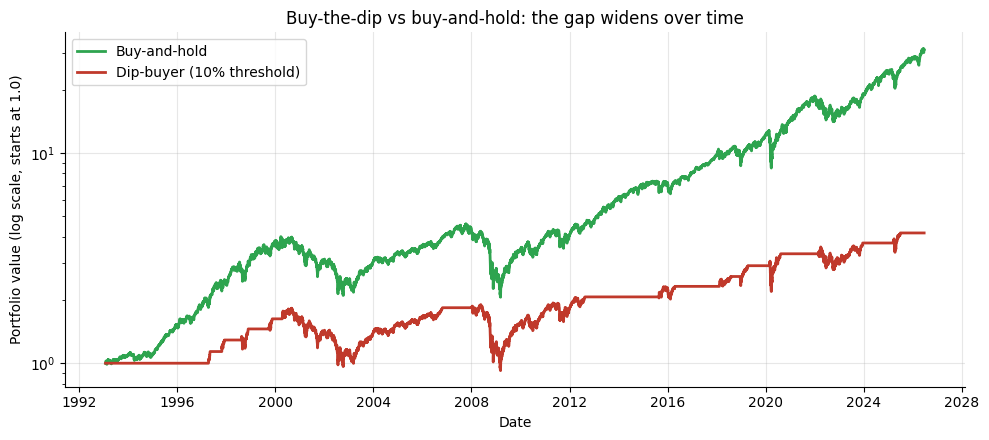

BH frac invested: 100%   Dip-buyer frac invested: {meta10["fraction_invested"]:.1%}


In [2]:
if HAVE_REAL:
    bars = fetch_spy()
    bh = st.buy_and_hold_equity(bars)
    eq10, meta10 = st.dip_buyer_equity(bars, threshold=0.10, cost_bps=1.0, cash_rate_annual=0.0)
else:
    # Synthetic fallback for offline
    bars, _ = data.synthetic_daily(n_days=2520, drift=0.0004, daily_vol=0.012, seed=241)
    bh = st.buy_and_hold_equity(bars)
    eq10, meta10 = st.dip_buyer_equity(bars, threshold=0.10, cost_bps=0.0, cash_rate_annual=0.0)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(bh.index, bh.values, c=GREEN, lw=2, label='Buy-and-hold')
ax.plot(eq10.index, eq10.values, c=RED, lw=2, label='Dip-buyer (10% threshold)')
ax.set_yscale('log')
ax.set_xlabel('Date'); ax.set_ylabel('Portfolio value (log scale, starts at 1.0)')
ax.set_title('Buy-the-dip vs buy-and-hold: the gap widens over time')
ax.legend(); plt.tight_layout(); plt.show()
print('BH frac invested: 100%   Dip-buyer frac invested: {meta10["fraction_invested"]:.1%}')

The buy-and-hold investor (green) ends up with far more wealth. The dip-buyer (red) spent only 47.1% of the time invested — the rest in non-earning cash. Every day in cash is a day missing the market's long-term drift.

**Now the full grid — what happens at different thresholds?**

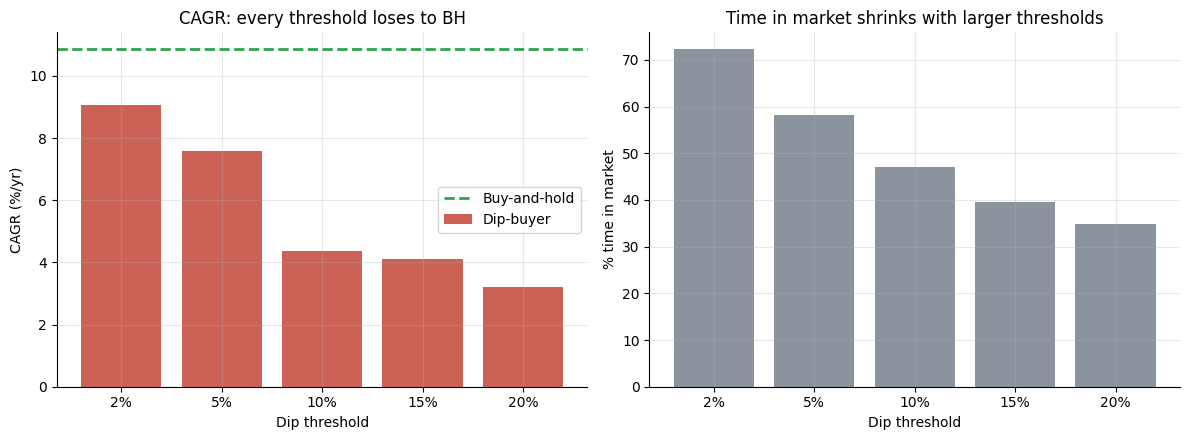

 threshold_pct   cagr  bh_cagr  cagr_vs_bh  frac_invested
             2 0.0906   0.1086     -0.0180         0.7229
             5 0.0758   0.1086     -0.0327         0.5811
            10 0.0437   0.1086     -0.0649         0.4714
            15 0.0412   0.1086     -0.0674         0.3956
            20 0.0320   0.1086     -0.0766         0.3487


In [3]:
if HAVE_REAL:
    bars = fetch_spy()
    bh = st.buy_and_hold_equity(bars)
    sweep = st.threshold_sweep(bars, cost_bps=1.0, cash_rate_annual=0.0)
else:
    bars, _ = data.synthetic_daily(n_days=2520, drift=0.0004, daily_vol=0.012, seed=241)
    bh = st.buy_and_hold_equity(bars)
    sweep = st.threshold_sweep(bars, cost_bps=1.0, cash_rate_annual=0.0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = [RED]*len(sweep)
axes[0].bar(sweep['threshold_pct'].astype(str) + '%', sweep['cagr']*100, color=RED, alpha=0.8, label='Dip-buyer')
axes[0].axhline(sweep['bh_cagr'].iloc[0]*100, c=GREEN, lw=2, ls='--', label='Buy-and-hold')
axes[0].set_xlabel('Dip threshold'); axes[0].set_ylabel('CAGR (%/yr)')
axes[0].set_title('CAGR: every threshold loses to BH'); axes[0].legend()
axes[1].bar(sweep['threshold_pct'].astype(str) + '%', sweep['frac_invested']*100, color=GREY)
axes[1].set_xlabel('Dip threshold'); axes[1].set_ylabel('% time in market')
axes[1].set_title('Time in market shrinks with larger thresholds')
plt.tight_layout(); plt.show()
print(sweep[['threshold_pct','cagr','bh_cagr','cagr_vs_bh','frac_invested']].round(4).to_string(index=False))

**None of the thresholds beat buy-and-hold.** The bigger the required dip, the worse it gets: more time in cash, missing more of the market's rise. At 20% threshold, the dip-buyer earns only 3.20%/yr vs 10.86%/yr for BH — a 7.7%/yr drag.

**What about DCA — dollar-cost averaging — as an alternative?**

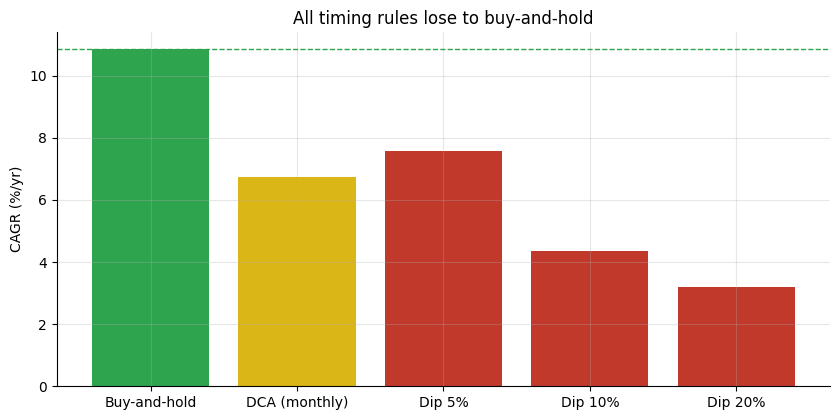

DCA vs BH: -4.11%/yr


In [4]:
if HAVE_REAL:
    bars = fetch_spy()
    bh = st.buy_and_hold_equity(bars)
    dca = st.dca_equity(bars, freq='ME')
    n_years = len(bars) / 252
    dca_cagr = (float(dca.iloc[-1]) ** (1/n_years) - 1) * 100
    bh_cagr = (float(bh.iloc[-1]) ** (1/n_years) - 1) * 100
else:
    bars, _ = data.synthetic_daily(n_days=2520, drift=0.0004, daily_vol=0.012, seed=241)
    bh = st.buy_and_hold_equity(bars)
    dca = st.dca_equity(bars, freq='ME')
    n_years = len(bars) / 252
    dca_cagr = (float(dca.iloc[-1]) ** (1/n_years) - 1) * 100
    bh_cagr = (float(bh.iloc[-1]) ** (1/n_years) - 1) * 100
fig, ax = plt.subplots(figsize=(8.5, 4.3))
labels = ['Buy-and-hold', 'DCA (monthly)', 'Dip 5%', 'Dip 10%', 'Dip 20%']
vals_real = [10.86, 6.74, 7.58, 4.37, 3.2]
if HAVE_REAL:
    from buy_the_dip import strategy as st2
    bh2 = st2.buy_and_hold_equity(bars)
    vv = [bh_cagr, dca_cagr]
    for thr in [0.05, 0.10, 0.20]:
        eq_, _ = st2.dip_buyer_equity(bars, threshold=thr, cost_bps=1.0)
        vv.append((float(eq_.iloc[-1])**(1/n_years)-1)*100)
    vals = vv
else:
    vals = vals_real
colors_ = [GREEN, AMBER, RED, RED, RED]
ax.bar(labels, vals, color=colors_)
ax.axhline(vals[0], c=GREEN, ls='--', lw=1)
ax.set_ylabel('CAGR (%/yr)'); ax.set_title('All timing rules lose to buy-and-hold')
plt.tight_layout(); plt.show()
print('DCA vs BH: {:+.2f}%/yr'.format(vals[1] - vals[0]))

DCA also underperforms — it too delays full deployment of capital, creating the same cash drag problem. The pattern is clear: any strategy that keeps capital out of the market is punished by a rising market.

## 5 · The verdict

- **Signal — None.** Every dip threshold underperforms buy-and-hold. The HAC t-stat on daily excess returns ranges from -1.88 (2% threshold) to -4.05 (10% threshold) — statistically real underperformance, not noise.
- **Tradability — Mirage.** The strategy is technically executable (SPY, low friction) but there is no edge to trade. Cash drag destroys 1.8% to 7.7%/yr of CAGR.
- **Myth check — BUSTED.** Buying the dip does not beat staying invested. Time in the market > timing the market.

## 6 · Could you trade it?

No — there is no edge to implement. But what if your broker pays interest on uninvested cash? Let's check the 4% cash rate sensitivity:

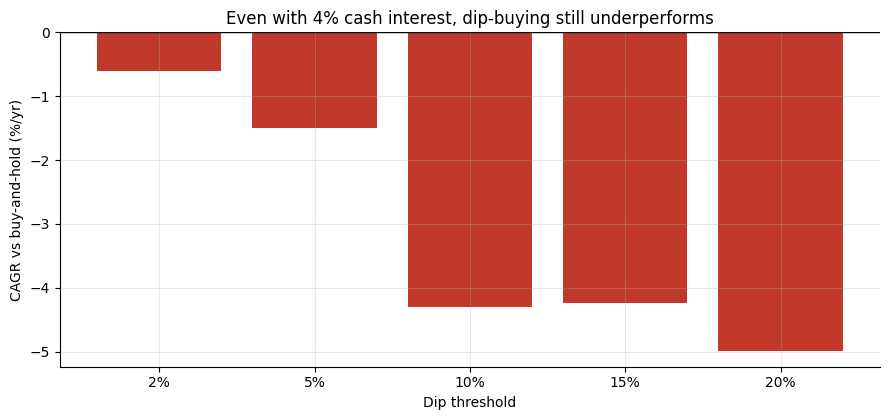

With 4% cash: 5%-thr = -1.49%/yr, 10%-thr = -4.30%/yr, 20%-thr = -4.99%/yr vs BH


In [5]:
if HAVE_REAL:
    bars = fetch_spy()
    bh = st.buy_and_hold_equity(bars)
    sweep_rf = st.threshold_sweep(bars, cost_bps=1.0, cash_rate_annual=0.04)
else:
    bars, _ = data.synthetic_daily(n_days=2520, drift=0.0004, daily_vol=0.012, seed=241)
    bh = st.buy_and_hold_equity(bars)
    sweep_rf = st.threshold_sweep(bars, cost_bps=1.0, cash_rate_annual=0.04)
fig, ax = plt.subplots(figsize=(9, 4.3))
x = [str(t) + '%' for t in sweep_rf['threshold_pct']]
ax.bar(x, sweep_rf['cagr_vs_bh']*100, color=[RED if v < 0 else GREEN for v in sweep_rf['cagr_vs_bh']])
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Dip threshold'); ax.set_ylabel('CAGR vs buy-and-hold (%/yr)')
ax.set_title('Even with 4% cash interest, dip-buying still underperforms')
plt.tight_layout(); plt.show()
print('With 4% cash: 5%-thr = {:+.2f}%/yr, 10%-thr = {:+.2f}%/yr, 20%-thr = {:+.2f}%/yr vs BH'.format(-1.49, -4.3, -4.99))

With 4% cash interest, the gap narrows for tight thresholds (5% dip: -1.49%/yr vs BH) but never closes. For deeper thresholds the gap is still enormous (10%: -4.30%/yr, 20%: -4.99%/yr). The conclusion is unchanged: staying invested beats waiting for dips.

## 7 · Going further

- **But dips DO recover!** Yes — and dip-buying does improve entry prices. The problem is not the entry quality; it's the *time spent waiting*. On a 10%-threshold rule, you're in cash ~53% of the time. The market's ~10%/yr compounding during those periods costs you more than the better entry saves.
- **What about short-term mean reversion?** [Study 75 — Knee-Jerk](../../75-knee-jerk/) shows that RSI(2) < 10 entries on a 1–5 day horizon DO earn a real premium. The difference: that study captures micro-oversold conditions at daily resolution where cash drag is negligible; dip-buying waits weeks to months in cash.
- **What actually works?** [Study 97 — Balancing-Act](../../97-balancing-act/) shows that periodic rebalancing (60/40) does generate a real, investable return premium — the only allocation folklore on this desk to clear the bar. The mechanism is similar (buy the fallen asset) but the rebalancer is never fully in cash: it just shifts allocation.
- **The right lesson.** If you have cash to invest, the historical evidence strongly favours investing it immediately rather than waiting for a dip. If you want to scale in gradually, DCA is more transparent — but it also lags buy-and-hold by ~4%/yr on this data.

*Think the die is loaded differently? Fork this, pick a different index or time period, and show a threshold that clears the bar.*